# ResNet18 Chess Piece Classifier Training

**Goal:** Train a 12-class chess piece classifier (no "empty" class) using single-piece images.

**Pipeline:**
1. Load dataset from `data/raw/all_resized_into_sub_folders_640/` (12 classes: Black/White pieces)
2. Map class names to canonical labels (black-bishop, white-king, etc.)
3. Split into train/val (80/20) with reproducible seed
4. Train ResNet18 with fine-tuning strategy (warmup → full fine-tune)
5. Save best checkpoint and evaluation metrics
6. Generate confusion matrix and sample predictions

**Classes:** black-bishop, black-king, black-knight, black-pawn, black-queen, black-rook, white-bishop, white-king, white-knight, white-pawn, white-queen, white-rook

In [ ]:
import os
import sys
from google.colab import drive

PROJECT_REL_PATH = 'COMP411/assignments/COMP-411_Project/chessvision/notebooks'
MOUNT_POINT = '/content/drive'

def setup_environment():
    # 1. Mount Drive if not already mounted
    if not os.path.exists(MOUNT_POINT):
        print("Mounting Google Drive...")
        drive.mount(MOUNT_POINT)
    else:
        print("Drive already mounted.")

    full_path = os.path.join(MOUNT_POINT, 'MyDrive', PROJECT_REL_PATH)

    # 2. Navigate to the directory
    try:
        os.chdir(full_path)
        if full_path not in sys.path:
            sys.path.append(full_path)

    except FileNotFoundError:
        print(f"ERROR: Path not found: {full_path}")

# Run the setup
setup_environment()

Mounting Google Drive...
Mounted at /content/drive


In [ ]:
# Install required packages if not available
import subprocess
import sys

def install_package(package):
    """Install a package if not already installed."""
    try:
        __import__(package)
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])

# Install PyTorch and sklearn if needed
try:
    import torch
    import torchvision
    import sklearn
    print("✓ PyTorch, torchvision, and sklearn are available")
except ImportError:
    print("Installing required packages...")
    install_package("torch")
    install_package("torchvision")
    install_package("scikit-learn")
    install_package("seaborn")
    import torch
    import torchvision
    import sklearn
    print("✓ Installation complete")

# Standard imports
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# PyTorch imports
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Set up paths
possible_roots = [
    Path.cwd().parent,  # If running from notebooks/ directory
    Path.cwd(),         # If running from workspace root
]

PROJECT_ROOT = None
for root in possible_roots:
    test_path = root / "data" / "raw" / "all_resized_into_sub_folders_640"
    if test_path.exists():
        PROJECT_ROOT = root
        break

if PROJECT_ROOT is None:
    PROJECT_ROOT = Path.cwd()

# Paths
DATA_ROOT = PROJECT_ROOT / "data" / "raw" / "all_resized_into_sub_folders_640"
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed" / "piece_classifier"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Training hyperparameters
BATCH_SIZE = 32
NUM_EPOCHS = 20
LEARNING_RATE = 1e-3
WARMUP_EPOCHS = 2  # Train only final layer for warmup
EARLY_STOP_PATIENCE = 5
RANDOM_SEED = 42
TRAIN_SPLIT = 0.8

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"Project root: {PROJECT_ROOT}")
print(f"Data root: {DATA_ROOT}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Device: {DEVICE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Total epochs: {NUM_EPOCHS} (warmup: {WARMUP_EPOCHS})")

✓ PyTorch, torchvision, and sklearn are available
Project root: /Users/ibrahimcbc/Library/CloudStorage/GoogleDrive-icebecioglu21@ku.edu.tr/My Drive/COMP411/assignments/COMP-411_Project/chessvision
Data root: /Users/ibrahimcbc/Library/CloudStorage/GoogleDrive-icebecioglu21@ku.edu.tr/My Drive/COMP411/assignments/COMP-411_Project/chessvision/data/raw/all_resized_into_sub_folders_640
Output directory: /Users/ibrahimcbc/Library/CloudStorage/GoogleDrive-icebecioglu21@ku.edu.tr/My Drive/COMP411/assignments/COMP-411_Project/chessvision/data/processed/piece_classifier
Device: cpu
Batch size: 32
Total epochs: 20 (warmup: 2)


## A) Sanity Checks: Discover Classes and Create Canonical Mapping

In [ ]:
# Discover class folders
if not DATA_ROOT.exists():
    raise FileNotFoundError(f"Data directory not found: {DATA_ROOT}")

class_folders = sorted([d.name for d in DATA_ROOT.iterdir() if d.is_dir()])
print(f"Found {len(class_folders)} class folders:")
for folder in class_folders:
    print(f"  - {folder}")

# Create canonical mapping: folder name -> canonical label
def normalize_class_name(folder_name):
    """Convert folder name to canonical label (e.g., 'Black bishop' -> 'black-bishop')."""
    # Normalize: lowercase, replace spaces with hyphens
    canonical = folder_name.lower().strip().replace(' ', '-')
    return canonical

# Build mapping
folder_to_canonical = {folder: normalize_class_name(folder) for folder in class_folders}
canonical_classes = sorted(set(folder_to_canonical.values()))

print(f"\nCanonical class labels ({len(canonical_classes)}):")
for canonical in canonical_classes:
    print(f"  - {canonical}")

# Expected classes
expected_classes = [
    'black-bishop', 'black-king', 'black-knight', 'black-pawn', 'black-queen', 'black-rook',
    'white-bishop', 'white-king', 'white-knight', 'white-pawn', 'white-queen', 'white-rook'
]

if set(canonical_classes) != set(expected_classes):
    print(f"\n⚠️ Warning: Expected 12 classes, found {len(canonical_classes)}")
    missing = set(expected_classes) - set(canonical_classes)
    extra = set(canonical_classes) - set(expected_classes)
    if missing:
        print(f"  Missing: {missing}")
    if extra:
        print(f"  Extra: {extra}")
else:
    print(f"\n✓ All 12 expected classes found!")

# Create reverse mapping for later use
canonical_to_idx = {canonical: idx for idx, canonical in enumerate(sorted(canonical_classes))}
idx_to_canonical = {idx: canonical for canonical, idx in canonical_to_idx.items()}

print(f"\nClass to index mapping:")
for canonical, idx in sorted(canonical_to_idx.items()):
    print(f"  {idx:2d}: {canonical}")

Found 12 class folders:
  - Black bishop
  - Black king
  - Black knight
  - Black pawn
  - Black queen
  - Black rook
  - White bishop
  - White king
  - White knight
  - White pawn
  - White queen
  - White rook

Canonical class labels (12):
  - black-bishop
  - black-king
  - black-knight
  - black-pawn
  - black-queen
  - black-rook
  - white-bishop
  - white-king
  - white-knight
  - white-pawn
  - white-queen
  - white-rook

✓ All 12 expected classes found!

Class to index mapping:
   0: black-bishop
   1: black-king
   2: black-knight
   3: black-pawn
   4: black-queen
   5: black-rook
   6: white-bishop
   7: white-king
   8: white-knight
   9: white-pawn
  10: white-queen
  11: white-rook


## B) Create Custom Dataset with Canonical Labels

In [ ]:
class CanonicalImageFolder(datasets.ImageFolder):
    """ImageFolder that maps folder names to canonical class labels."""

    def __init__(self, root, folder_to_canonical, canonical_to_idx, transform=None):
        self.folder_to_canonical = folder_to_canonical
        self.canonical_to_idx = canonical_to_idx

        # Call parent to load images
        super().__init__(root, transform=transform)

        # Store original classes and mapping
        self.original_classes = self.classes.copy()
        self.original_class_to_idx = self.class_to_idx.copy()

        # Remap to canonical classes
        self.classes = sorted(canonical_to_idx.keys())
        self.class_to_idx = canonical_to_idx

        # Remap samples: (path, original_idx) -> (path, canonical_idx)
        remapped_samples = []
        for path, orig_idx in self.samples:
            # Get original folder name
            orig_class_name = self.original_classes[orig_idx]
            # Map to canonical
            canonical_name = folder_to_canonical[orig_class_name]
            # Get canonical index
            canonical_idx = canonical_to_idx[canonical_name]
            remapped_samples.append((path, canonical_idx))

        self.samples = remapped_samples

# Create dataset
full_dataset = CanonicalImageFolder(
    root=str(DATA_ROOT),
    folder_to_canonical=folder_to_canonical,
    canonical_to_idx=canonical_to_idx,
    transform=None  # Will apply transforms in DataLoader
)

print(f"Total images: {len(full_dataset)}")
print(f"Number of classes: {len(full_dataset.classes)}")

# Count images per class
class_counts = Counter([full_dataset.classes[idx] for _, idx in full_dataset.samples])
print(f"\nImages per class:")
for canonical in sorted(class_counts.keys()):
    print(f"  {canonical:20s}: {class_counts[canonical]:4d} images")

Total images: 300
Number of classes: 12

Images per class:
  black-bishop        :   25 images
  black-king          :   25 images
  black-knight        :   25 images
  black-pawn          :   25 images
  black-queen         :   25 images
  black-rook          :   25 images
  white-bishop        :   25 images
  white-king          :   25 images
  white-knight        :   25 images
  white-pawn          :   25 images
  white-queen         :   25 images
  white-rook          :   25 images


## C) Create Train/Val Split and Data Loaders

In [ ]:
# Set random seed for reproducibility
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Split dataset
train_size = int(TRAIN_SPLIT * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(RANDOM_SEED)
)

print(f"Train size: {len(train_dataset)}")
print(f"Val size: {len(val_dataset)}")

# Define transforms
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Apply transforms to datasets
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform

# Create data loaders (num_workers=0 for compatibility, can be increased if needed)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"\n✓ Data loaders created")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

# DEBUG: Validate dataset and dataloaders
print("\n" + "="*60)
print("DATASET VALIDATION")
print("="*60)
print(f"Train dataset size: {len(train_dataset)}")
print(f"Val dataset size: {len(val_dataset)}")
print(f"Train loader batches: {len(train_loader)}")
print(f"Val loader batches: {len(val_loader)}")
if hasattr(train_dataset, 'dataset') and hasattr(train_dataset.dataset, 'classes'):
    print(f"Class names: {train_dataset.dataset.classes}")
elif hasattr(train_dataset, 'classes'):
    print(f"Class names: {train_dataset.classes}")
else:
    print("Class names: (not available)")

# Sanity check: show one batch shape
try:
    sample_batch = next(iter(train_loader))
    images, labels = sample_batch
    print(f"\nSample batch shape:")
    print(f"  Images: {images.shape} (batch_size, channels, height, width)")
    print(f"  Labels: {labels.shape} (batch_size,)")
    print(f"  Label range: {labels.min().item()} to {labels.max().item()}")
    print(f"  First 10 labels: {labels[:10].tolist()}")
    print("✓ Batch loading successful")
except Exception as e:
    print(f"\n✗ ERROR loading batch: {e}")
    raise
print("="*60)

Train size: 240
Val size: 60

✓ Data loaders created
Train batches: 8
Val batches: 2

DATASET VALIDATION
Train dataset size: 240
Val dataset size: 60
Train loader batches: 8
Val loader batches: 2
Class names: ['black-bishop', 'black-king', 'black-knight', 'black-pawn', 'black-queen', 'black-rook', 'white-bishop', 'white-king', 'white-knight', 'white-pawn', 'white-queen', 'white-rook']

Sample batch shape:
  Images: torch.Size([32, 3, 224, 224]) (batch_size, channels, height, width)
  Labels: torch.Size([32]) (batch_size,)
  Label range: 0 to 11
  First 10 labels: [9, 2, 8, 1, 7, 11, 9, 3, 9, 1]
✓ Batch loading successful


## D) Initialize ResNet18 Model

In [ ]:
def create_resnet18_model(num_classes=12):
    """Create ResNet18 model with pretrained weights and custom classifier head."""
    model = models.resnet18(weights='IMAGENET1K_V1')

    # Freeze all layers initially
    for param in model.parameters():
        param.requires_grad = False

    # Replace final fully connected layer
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, num_classes)

    # Unfreeze the new classifier
    for param in model.fc.parameters():
        param.requires_grad = True

    return model

model = create_resnet18_model(num_classes=len(canonical_classes))
model = model.to(DEVICE)

print(f"✓ ResNet18 model created")
print(f"  Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# Save label map
label_map = {
    'id_to_name': idx_to_canonical,
    'name_to_id': canonical_to_idx
}
label_map_path = OUTPUT_DIR / "label_map.json"
with open(label_map_path, 'w') as f:
    json.dump(label_map, f, indent=2)
print(f"\n✓ Label map saved to: {label_map_path}")

✓ ResNet18 model created
  Total parameters: 11,182,668
  Trainable parameters: 6,156

✓ Label map saved to: /Users/ibrahimcbc/Library/CloudStorage/GoogleDrive-icebecioglu21@ku.edu.tr/My Drive/COMP411/assignments/COMP-411_Project/chessvision/data/processed/piece_classifier/label_map.json


## E) Training Loop with Fine-Tuning Strategy

In [ ]:
# Loss, optimizer, scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0.0
best_epoch = 0
patience_counter = 0

def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc

def validate(model, loader, criterion, device):
    """Validate model."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc, all_preds, all_labels

print("Starting training...\n")

# DEBUG: Verify training will run
print("="*60)
print("TRAINING PRE-FLIGHT CHECKS")
print("="*60)
print(f"NUM_EPOCHS: {NUM_EPOCHS}")
print(f"WARMUP_EPOCHS: {WARMUP_EPOCHS}")
print(f"Train loader batches: {len(train_loader)}")
print(f"Val loader batches: {len(val_loader)}")
if len(train_loader) == 0:
    raise ValueError("ERROR: Train loader is empty! Check dataset path and structure.")
if len(val_loader) == 0:
    raise ValueError("ERROR: Val loader is empty! Check dataset path and structure.")
print("✓ All checks passed - training will proceed")
print("="*60 + "\n")

Starting training...

TRAINING PRE-FLIGHT CHECKS
NUM_EPOCHS: 20
WARMUP_EPOCHS: 2
Train loader batches: 8
Val loader batches: 2
✓ All checks passed - training will proceed



In [ ]:
# Training loop
print("Entering training loop...")
prev_freeze_backbone = None
for epoch in range(NUM_EPOCHS):
    print(f"Processing epoch {epoch+1}/{NUM_EPOCHS}...")  # Debug print
    # Determine if we're in warmup phase
    freeze_backbone = (epoch < WARMUP_EPOCHS)
    phase = "WARMUP" if freeze_backbone else "FINE-TUNE"

    # Set requires_grad for all parameters based on phase
    if freeze_backbone:
        for name, param in model.named_parameters():
            param.requires_grad = ('fc' in name)
    else:
        for param in model.parameters():
            param.requires_grad = True

    # Recreate optimizer when switching phases (to update parameter groups)
    if prev_freeze_backbone is not None and prev_freeze_backbone != freeze_backbone:
        print(f"  Switching to {phase} phase - recreating optimizer...")
        # Get current learning rate
        current_lr = optimizer.param_groups[0]['lr']
        # Recreate optimizer with all trainable parameters
        optimizer = optim.AdamW(
            [p for p in model.parameters() if p.requires_grad],
            lr=current_lr,
            weight_decay=1e-4
        )
        # Recreate scheduler (without verbose for compatibility)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    prev_freeze_backbone = freeze_backbone

    # Train
    try:
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    except Exception as e:
        print(f"ERROR in train_epoch: {e}")
        raise

    # Validate
    try:
        val_loss, val_acc, val_preds, val_labels = validate(model, val_loader, criterion, DEVICE)
    except Exception as e:
        print(f"ERROR in validate: {e}")
        raise

    # Update scheduler
    try:
        scheduler.step(val_loss)
    except Exception as e:
        print(f"WARNING: Scheduler step failed: {e}")
        # Continue training even if scheduler fails

    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Print progress
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] ({phase})")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        patience_counter = 0

        best_model_path = OUTPUT_DIR / "resnet18_best.pth"
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
            'label_map': label_map
        }, str(best_model_path))
        print(f"  ✓ Saved best model (val_acc: {val_acc:.2f}%)")
    else:
        patience_counter += 1

    # Save last model
    last_model_path = OUTPUT_DIR / "resnet18_last.pth"
    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_acc': val_acc,
        'val_loss': val_loss,
        'label_map': label_map
    }, str(last_model_path))

    # Early stopping
    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping triggered (patience: {EARLY_STOP_PATIENCE})")
        break

    print()

print(f"\nTraining complete!")
print(f"Best validation accuracy: {best_val_acc:.2f}% (epoch {best_epoch})")
print(f"Best model saved to: {OUTPUT_DIR / 'resnet18_best.pth'}")
print(f"Last model saved to: {OUTPUT_DIR / 'resnet18_last.pth'}")

Entering training loop...
Processing epoch 1/20...
Epoch [1/20] (WARMUP)
  Train Loss: 2.5083 | Train Acc: 9.58%
  Val Loss:   2.2230 | Val Acc:   20.00%
  LR: 0.001000
  ✓ Saved best model (val_acc: 20.00%)

Processing epoch 2/20...
Epoch [2/20] (WARMUP)
  Train Loss: 2.1125 | Train Acc: 30.42%
  Val Loss:   1.8639 | Val Acc:   43.33%
  LR: 0.001000
  ✓ Saved best model (val_acc: 43.33%)

Processing epoch 3/20...
  Switching to FINE-TUNE phase - recreating optimizer...
Epoch [3/20] (FINE-TUNE)
  Train Loss: 0.9114 | Train Acc: 70.83%
  Val Loss:   5.1332 | Val Acc:   45.00%
  LR: 0.001000
  ✓ Saved best model (val_acc: 45.00%)

Processing epoch 4/20...
Epoch [4/20] (FINE-TUNE)
  Train Loss: 0.2416 | Train Acc: 93.33%
  Val Loss:   1.8141 | Val Acc:   76.67%
  LR: 0.001000
  ✓ Saved best model (val_acc: 76.67%)

Processing epoch 5/20...
Epoch [5/20] (FINE-TUNE)
  Train Loss: 0.0835 | Train Acc: 97.92%
  Val Loss:   0.2560 | Val Acc:   88.33%
  LR: 0.001000
  ✓ Saved best model (val_acc

## F) Evaluation: Confusion Matrix

✓ Confusion matrix saved to: /Users/ibrahimcbc/Library/CloudStorage/GoogleDrive-icebecioglu21@ku.edu.tr/My Drive/COMP411/assignments/COMP-411_Project/chessvision/data/processed/piece_classifier/confusion_matrix.png


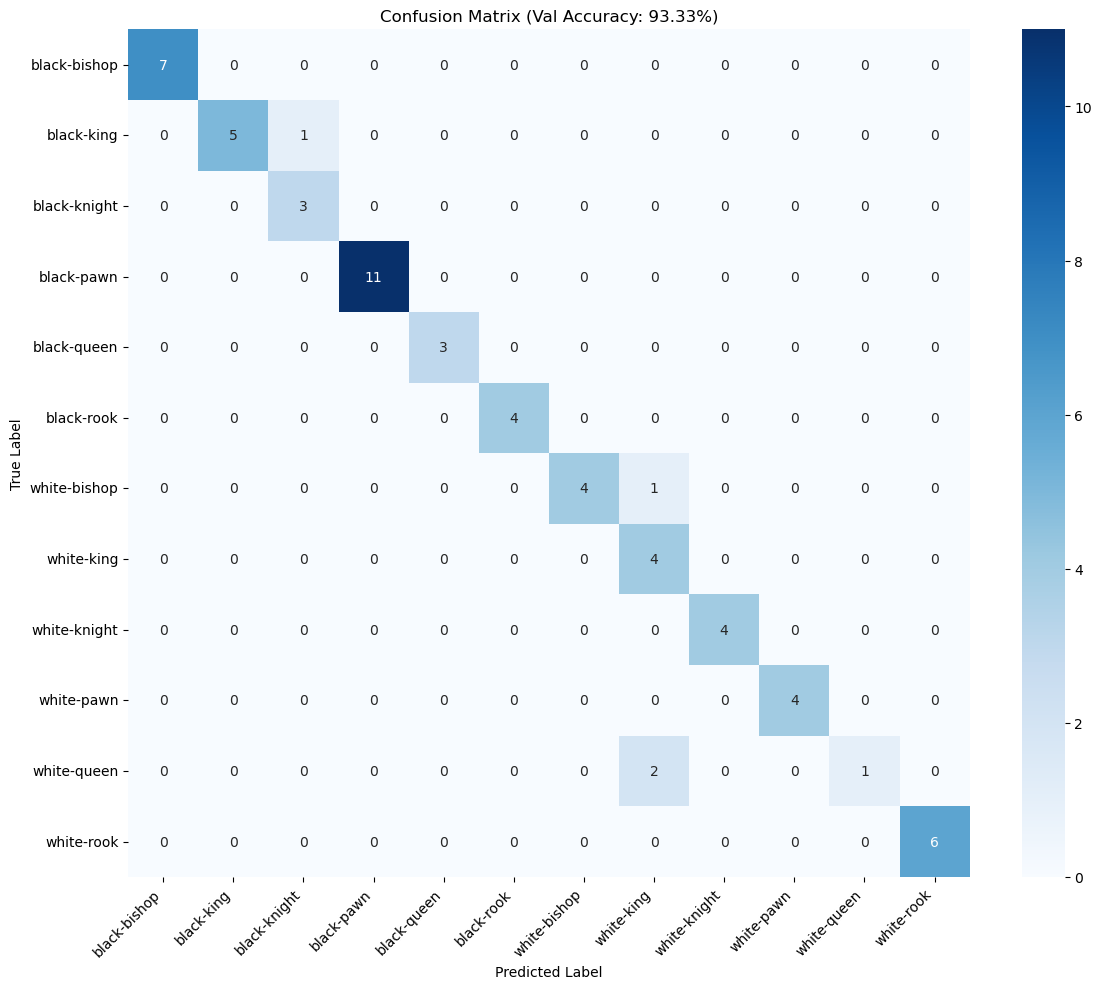


Classification Report:
              precision    recall  f1-score   support

black-bishop      1.000     1.000     1.000         7
  black-king      1.000     0.833     0.909         6
black-knight      0.750     1.000     0.857         3
  black-pawn      1.000     1.000     1.000        11
 black-queen      1.000     1.000     1.000         3
  black-rook      1.000     1.000     1.000         4
white-bishop      1.000     0.800     0.889         5
  white-king      0.571     1.000     0.727         4
white-knight      1.000     1.000     1.000         4
  white-pawn      1.000     1.000     1.000         4
 white-queen      1.000     0.333     0.500         3
  white-rook      1.000     1.000     1.000         6

    accuracy                          0.933        60
   macro avg      0.943     0.914     0.907        60
weighted avg      0.959     0.933     0.931        60



In [ ]:
# Load best model for evaluation
checkpoint = torch.load(str(OUTPUT_DIR / "resnet18_best.pth"), map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Get predictions on validation set
val_loss, val_acc, val_preds, val_labels = validate(model, val_loader, criterion, DEVICE)

# Compute confusion matrix
cm = confusion_matrix(val_labels, val_preds)
class_names = [idx_to_canonical[i] for i in range(len(canonical_classes))]

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix (Val Accuracy: {val_acc:.2f}%)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
cm_path = OUTPUT_DIR / "confusion_matrix.png"
plt.savefig(str(cm_path), dpi=150, bbox_inches='tight')
print(f"✓ Confusion matrix saved to: {cm_path}")
plt.show()

# Print classification report
print("\nClassification Report:")
print(classification_report(val_labels, val_preds, target_names=class_names, digits=3))

## G) Sample Predictions Visualization

✓ Sample predictions saved to: /Users/ibrahimcbc/Library/CloudStorage/GoogleDrive-icebecioglu21@ku.edu.tr/My Drive/COMP411/assignments/COMP-411_Project/chessvision/data/processed/piece_classifier/sample_predictions.png


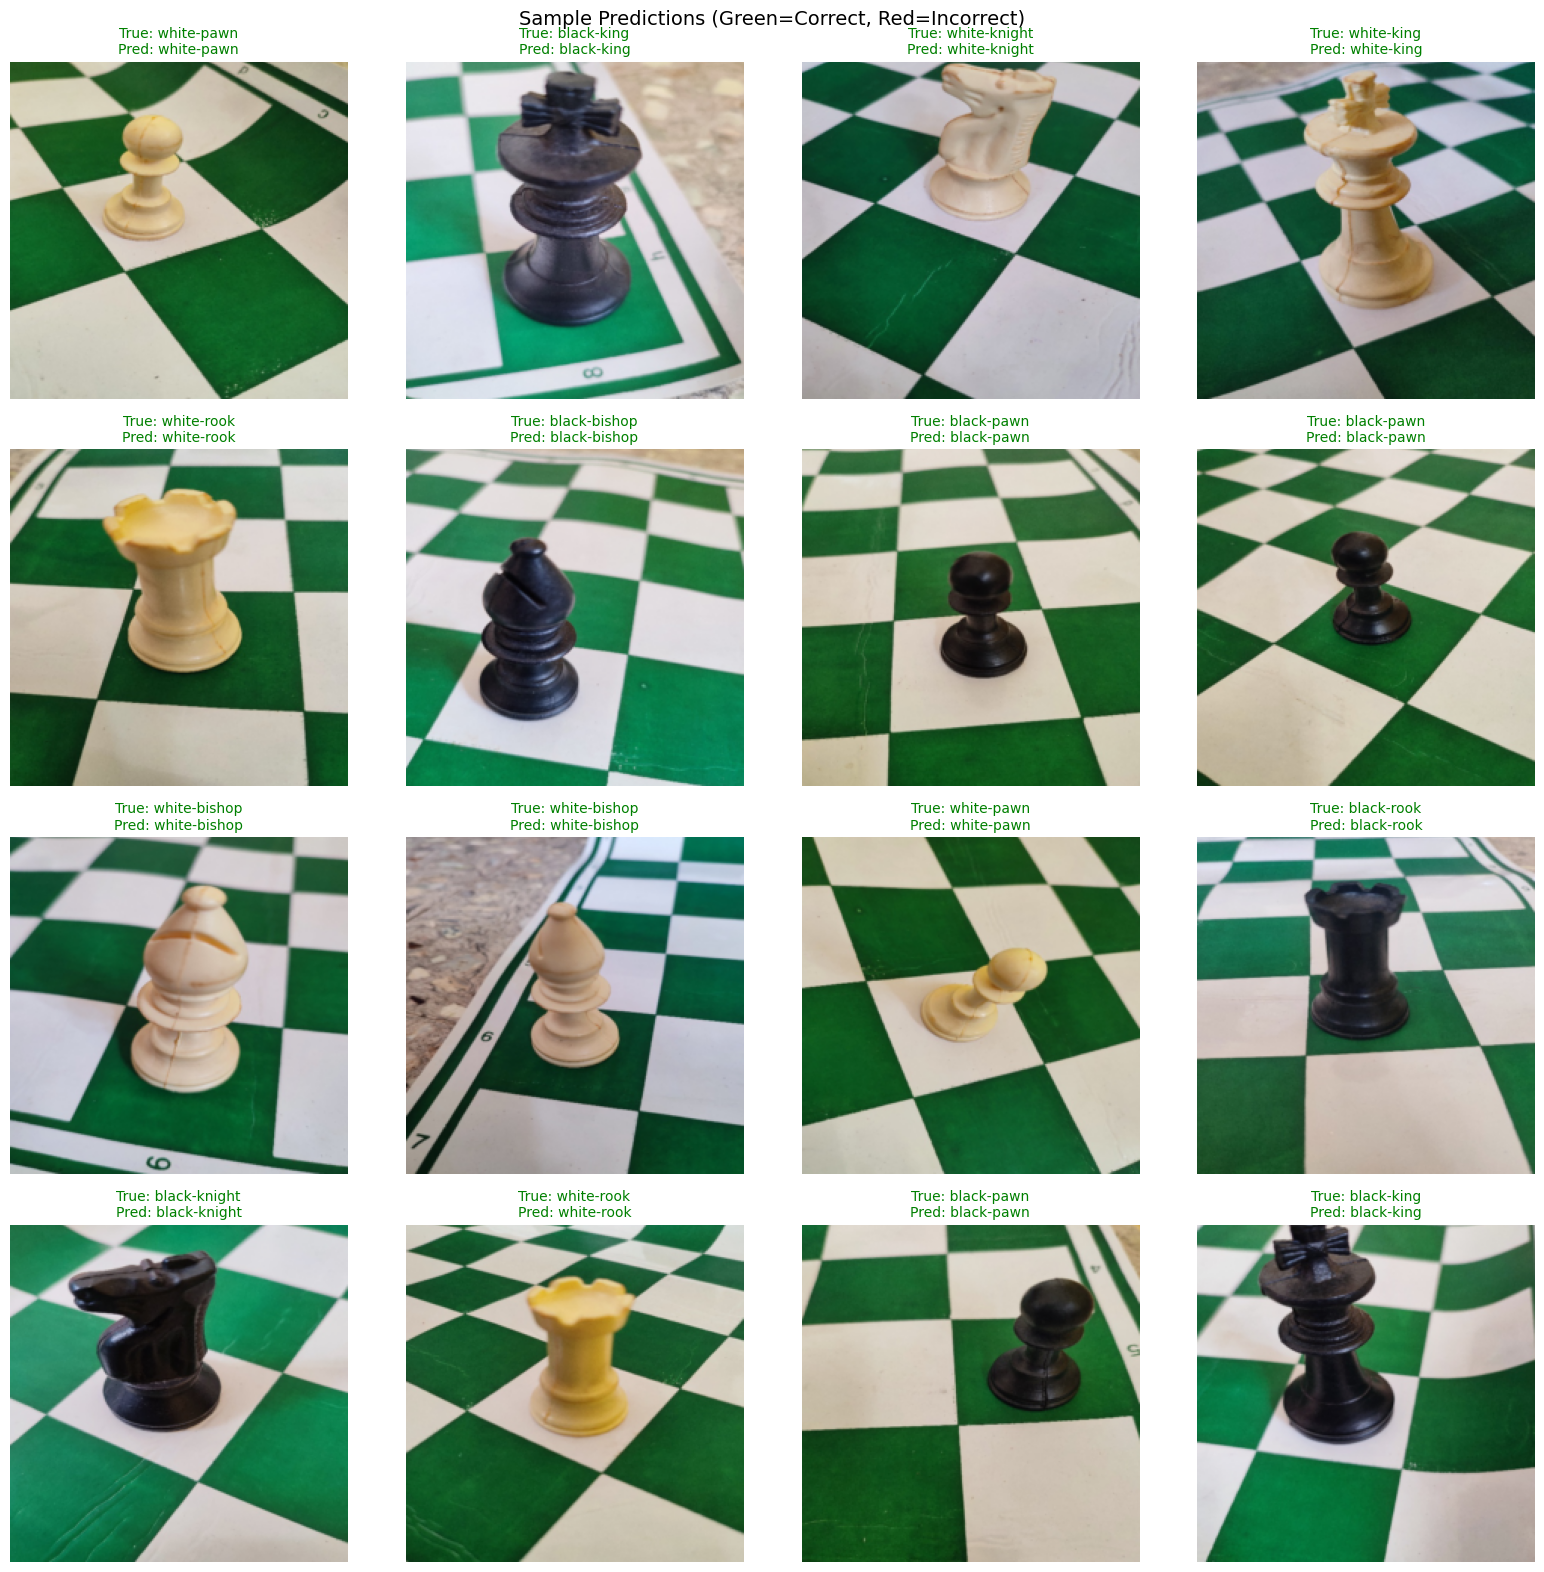

In [ ]:
# Get a batch of validation images
model.eval()
data_iter = iter(val_loader)
images, labels = next(data_iter)
images = images.to(DEVICE)

# Get predictions
with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

# Denormalize for visualization
def denormalize(tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    """Denormalize a tensor image."""
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor

# Visualize 16 samples
num_samples = min(16, len(images))
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.ravel()

for idx in range(num_samples):
    img = images[idx].cpu()
    img = denormalize(img.clone())
    img = torch.clamp(img, 0, 1)
    img = img.permute(1, 2, 0).numpy()

    true_label = idx_to_canonical[labels[idx].item()]
    pred_label = idx_to_canonical[preds[idx].item()]
    is_correct = (preds[idx] == labels[idx]).item()

    axes[idx].imshow(img)
    color = 'green' if is_correct else 'red'
    title = f"True: {true_label}\nPred: {pred_label}"
    axes[idx].set_title(title, color=color, fontsize=10)
    axes[idx].axis('off')

plt.suptitle(f'Sample Predictions (Green=Correct, Red=Incorrect)', fontsize=14)
plt.tight_layout()
samples_path = OUTPUT_DIR / "sample_predictions.png"
plt.savefig(str(samples_path), dpi=150, bbox_inches='tight')
print(f"✓ Sample predictions saved to: {samples_path}")
plt.show()

## H) Training Curves

✓ Training curves saved to: /Users/ibrahimcbc/Library/CloudStorage/GoogleDrive-icebecioglu21@ku.edu.tr/My Drive/COMP411/assignments/COMP-411_Project/chessvision/data/processed/piece_classifier/training_curves.png


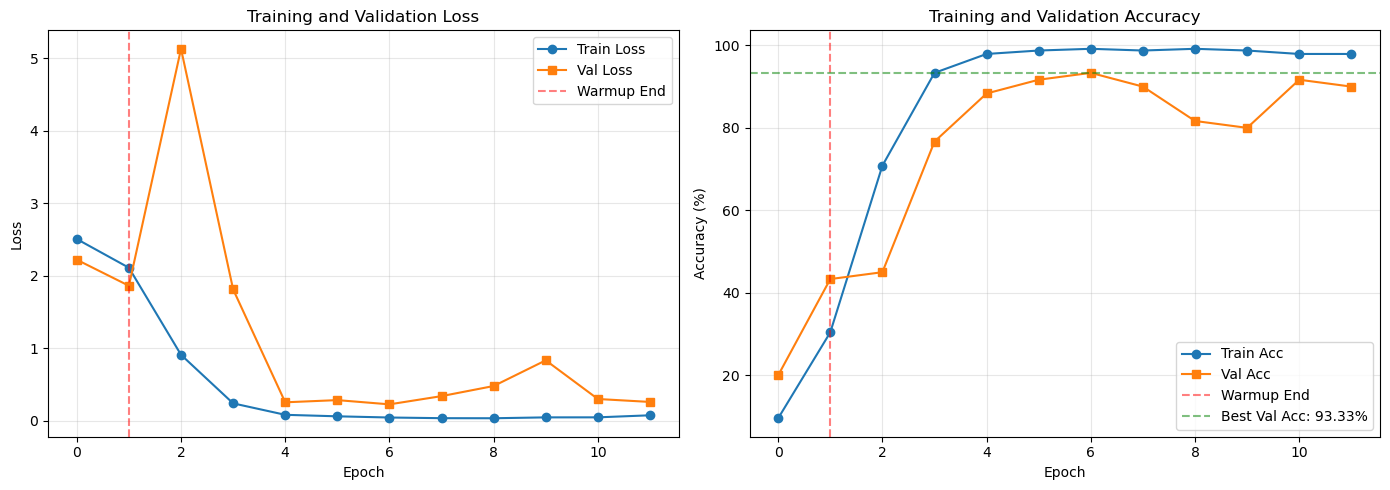

In [ ]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
axes[0].axvline(x=WARMUP_EPOCHS-1, color='r', linestyle='--', alpha=0.5, label='Warmup End')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(history['train_acc'], label='Train Acc', marker='o')
axes[1].plot(history['val_acc'], label='Val Acc', marker='s')
axes[1].axvline(x=WARMUP_EPOCHS-1, color='r', linestyle='--', alpha=0.5, label='Warmup End')
axes[1].axhline(y=best_val_acc, color='g', linestyle='--', alpha=0.5, label=f'Best Val Acc: {best_val_acc:.2f}%')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
curves_path = OUTPUT_DIR / "training_curves.png"
plt.savefig(str(curves_path), dpi=150, bbox_inches='tight')
print(f"✓ Training curves saved to: {curves_path}")
plt.show()

## I) Summary

In [ ]:
print("="*80)
print("TRAINING SUMMARY")
print("="*80)

print(f"\nDataset:")
print(f"  Total images: {len(full_dataset)}")
print(f"  Train images: {len(train_dataset)} ({100*len(train_dataset)/len(full_dataset):.1f}%)")
print(f"  Val images:   {len(val_dataset)} ({100*len(val_dataset)/len(full_dataset):.1f}%)")
print(f"  Number of classes: {len(canonical_classes)}")

print(f"\nClass distribution (total):")
for canonical in sorted(class_counts.keys()):
    print(f"  {canonical:20s}: {class_counts[canonical]:4d} images")

print(f"\nTraining:")
print(f"  Model: ResNet18 (pretrained)")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Total epochs: {len(history['train_loss'])}")
print(f"  Warmup epochs: {WARMUP_EPOCHS}")
print(f"  Learning rate: {LEARNING_RATE}")

print(f"\nResults:")
print(f"  Best validation accuracy: {best_val_acc:.2f}% (epoch {best_epoch})")
print(f"  Final train accuracy: {history['train_acc'][-1]:.2f}%")
print(f"  Final val accuracy: {history['val_acc'][-1]:.2f}%")
print(f"  Final train loss: {history['train_loss'][-1]:.4f}")
print(f"  Final val loss: {history['val_loss'][-1]:.4f}")

print(f"\nSaved files:")
print(f"  Best model: {OUTPUT_DIR / 'resnet18_best.pth'}")
print(f"  Last model: {OUTPUT_DIR / 'resnet18_last.pth'}")
print(f"  Label map:  {OUTPUT_DIR / 'label_map.json'}")
print(f"  Confusion matrix: {OUTPUT_DIR / 'confusion_matrix.png'}")
print(f"  Sample predictions: {OUTPUT_DIR / 'sample_predictions.png'}")
print(f"  Training curves: {OUTPUT_DIR / 'training_curves.png'}")

print("\n" + "="*80)

TRAINING SUMMARY

Dataset:
  Total images: 300
  Train images: 240 (80.0%)
  Val images:   60 (20.0%)
  Number of classes: 12

Class distribution (total):
  black-bishop        :   25 images
  black-king          :   25 images
  black-knight        :   25 images
  black-pawn          :   25 images
  black-queen         :   25 images
  black-rook          :   25 images
  white-bishop        :   25 images
  white-king          :   25 images
  white-knight        :   25 images
  white-pawn          :   25 images
  white-queen         :   25 images
  white-rook          :   25 images

Training:
  Model: ResNet18 (pretrained)
  Batch size: 32
  Total epochs: 12
  Warmup epochs: 2
  Learning rate: 0.001

Results:
  Best validation accuracy: 93.33% (epoch 7)
  Final train accuracy: 97.92%
  Final val accuracy: 90.00%
  Final train loss: 0.0769
  Final val loss: 0.2612

Saved files:
  Best model: /Users/ibrahimcbc/Library/CloudStorage/GoogleDrive-icebecioglu21@ku.edu.tr/My Drive/COMP411/assign